# KNN — Predict Whether a Person Will Have Diabetes

## Import all dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## Load diabetes.csv

In [2]:
diabetes_df = pd.read_csv('diabetes.csv')

## Examine the dataset

Print the number of rows and display the first few rows.
Note: `Outcome` = 1 means diabetic, 0 means not diabetic.

In [3]:
print(f"\nNumber of rows: {diabetes_df.shape[0]}")
diabetes_df.head()

# Column headers
headers = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


Number of rows: 768


## Data Processing

Some columns contain `0` as a placeholder for missing values — a glucose level or BMI of 0 is physiologically impossible.

### Step 1 — Identify the affected columns

In [4]:
zero_not_accepted = ['Glucose', 'BloodPressure', 'SkinThickness', 'BMI', 'Insulin']

# Boolean mask
mask = (diabetes_df[zero_not_accepted] == 0)

# Display affected columns
affected = mask.columns[mask.any()].tolist()
print(f"\nAffected columns:\n{affected}")


Affected columns:
['Glucose', 'BloodPressure', 'SkinThickness', 'BMI', 'Insulin']


### Step 2 — Replace zeros with each column's mean

For each column in `zero_not_accepted`:
1. Replace the `0` values with `np.nan`
2. Compute the column mean (skipping NaN)
3. Replace `np.nan` with that mean

In [5]:
# 1. Replace 0 values with nan
print(f"\nBefore replace:\n{(diabetes_df[affected] == 0).sum()}")
diabetes_df[affected] = diabetes_df[affected].replace(0, np.nan)

# 2. Compute column mean (auto skips NaN)
col_means = diabetes_df[affected].mean(axis = 0)
print(f"\nColumn mean values: {col_means}")

# 3. Replace nan with mean
diabetes_df[affected] = diabetes_df[affected].replace(np.nan, col_means)
print(f"\nZero count:\n{(diabetes_df[affected] == 0).sum()}")
print(f"\nNaN count:\n{(diabetes_df[affected].isna()).sum()}")


Before replace:
Glucose            5
BloodPressure     35
SkinThickness    227
BMI               11
Insulin          374
dtype: int64

Column mean values: Glucose          121.686763
BloodPressure     72.405184
SkinThickness     29.153420
BMI               32.457464
Insulin          155.548223
dtype: float64

Zero count:
Glucose          0
BloodPressure    0
SkinThickness    0
BMI              0
Insulin          0
dtype: int64

NaN count:
Glucose          0
BloodPressure    0
SkinThickness    0
BMI              0
Insulin          0
dtype: int64


## Feature Scaling

KNN uses distance to find neighbours. Because the features in this dataset have very different ranges (e.g. Insulin range ≈ 832, DiabetesPedigreeFunction range ≈ 2.3), features with larger ranges will dominate the distance calculation.

Use `StandardScaler` to rescale all features to mean=0, std=1.

> **Important:** fit the scaler on **training data only**, then apply it to both train and test sets.

## Split the dataset — 80% train, 20% test

Use `test_size=0.2` and `random_state=42`.

In [6]:
X = diabetes_df.drop('Outcome', axis = 1)
y = diabetes_df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

### Apply StandardScaler to the split data

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Original feature ranges (training set):")
print(X_train.describe().loc[['min', 'max']])
print("\nScaled feature ranges (training set):")
print(pd.DataFrame(X_train_scaled, columns = headers).describe().loc[['min', 'max']].round(2))

Original feature ranges (training set):
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
min          0.0     44.0           24.0            8.0     14.0  18.2   
max         17.0    199.0          122.0           63.0    846.0  67.1   

     DiabetesPedigreeFunction   Age  
min                     0.078  21.0  
max                     2.420  81.0  

Scaled feature ranges (training set):
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
min        -1.13    -2.59          -3.99          -2.47    -1.62 -2.04   
max         4.00     2.57           4.12           4.07     7.95  5.01   

     DiabetesPedigreeFunction   Age  
min                     -1.16 -1.04  
max                      5.80  4.18  


## Train the model

Create and fit a `KNeighborsClassifier`. A useful starting point for k is √(number of training samples), rounded to the nearest odd number.


K start value: 25

K value range: range(25, 615, 2)

y_train errors:
[0.21009771986970682, 0.21172638436482083, 0.21172638436482083, 0.21172638436482083, 0.22149837133550487]

y_test errors:
[0.2727272727272727, 0.2532467532467533, 0.2597402597402597, 0.2597402597402597, 0.2532467532467533]


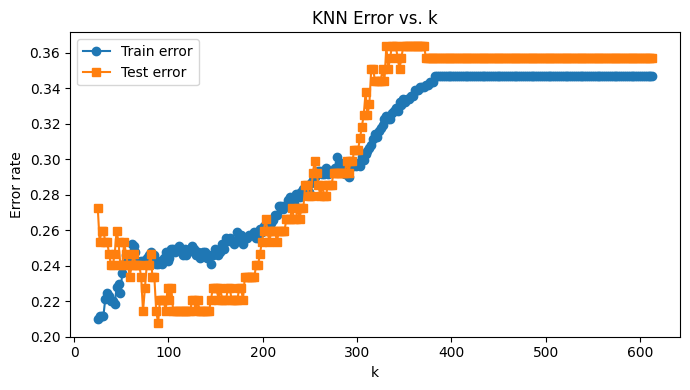

In [9]:
# training set length
X_train_len = len(X_train_scaled)

# Get sqrt of no. of training set as k_start
sqrt_X_len = int(np.sqrt(X_train_len))
k_start = sqrt_X_len if sqrt_X_len % 2 != 0 else sqrt_X_len + 1 # ensure odd num
print(f"\nK start value: {k_start}")

# Derive k values
k_values = range(k_start, X_train_len + 1, 2) # Odd values only
print(f"\nK value range: {k_values}")

# Errors
train_errors = []
test_errors = []

# Create and fit classifier
for k in k_values:
    model = KNeighborsClassifier(n_neighbors = k)
    model.fit(X_train_scaled, y_train)
    train_errors.append(1 - accuracy_score(y_train, model.predict(X_train_scaled)))
    test_errors.append(1 - accuracy_score(y_test, model.predict(X_test_scaled)))
print(f"\ny_train errors:\n{train_errors[:5]}")
print(f"\ny_test errors:\n{test_errors[:5]}")

plt.figure(figsize=(7, 4))
plt.plot(list(k_values), train_errors, marker='o', label='Train error')
plt.plot(list(k_values), test_errors,  marker='s', label='Test error')
plt.xlabel('k')
plt.ylabel('Error rate')
plt.title('KNN Error vs. k')
plt.legend()
plt.tight_layout()
plt.show()

## Predict on test data

In [15]:
# find best k
best_k_idx = np.argmin(test_errors)
best_k = list(k_values)[best_k_idx]
best_error = test_errors[best_k_idx]
print(f"\nBest k: {best_k}")
print(f"\nLowest test error: {best_error}")

# Use k to train model
knn_model = KNeighborsClassifier(n_neighbors = best_k)
knn_model.fit(X_train_scaled, y_train)

# Predict
y_pred = knn_model.predict(X_test_scaled)
print(y_pred)


Best k: 89

Lowest test error: 0.20779220779220775
[0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 1 1 1 1 1 1
 0 0 0 0 0 0 0 0 1 1 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 1 1 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 1 0 1 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0]


## Evaluate the model

Print the accuracy score, then plot a confusion matrix.

Think about which type of error is more costly in a medical setting: a false negative (diabetic predicted as healthy) or a false positive (healthy predicted as diabetic)?

In [17]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy score: {acc:.4f}")

Accuracy score: 0.7922


[[90  9]
 [23 32]]


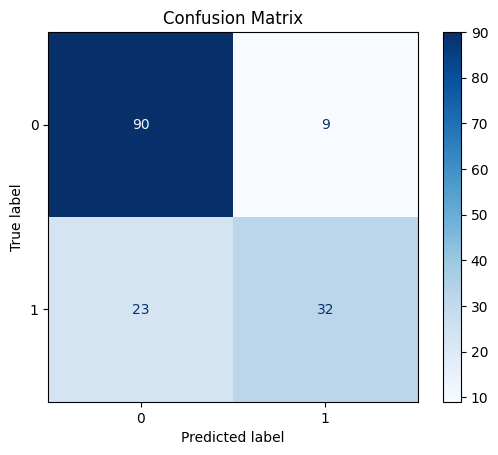

In [20]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

# plotting
ConfusionMatrixDisplay(confusion_matrix = cm).plot(cmap = 'Blues')

plt.title("Confusion Matrix")
plt.show()